In [225]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os


drive_path = '/content/drive/MyDrive/'
for root, dirs, files in os.walk(drive_path):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/ScienceDirect_articles_04Oct2021_10-23-58.617.zip
/content/drive/MyDrive/1001OverlappingSequenceDetectorDesign_20017004-PSpiceFiles.zip
/content/drive/MyDrive/drd.zip
/content/drive/MyDrive/iris.zip
/content/drive/MyDrive/Yetenek Sultanbeyli Ödev /Dosya Formatları ve Dönüşümler Görevi.zip


In [11]:
import zipfile

zip_path = '/content/drive/MyDrive/drd.zip'  # ZIP pathway
extract_path = '/content/dataset'  # output directory

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [12]:
import pandas as pd

csv_path = "/content/dataset/drd/train.csv"

df= pd.read_csv(csv_path, sep=',')
print(df.head())


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


Axes(0.125,0.11;0.775x0.77)


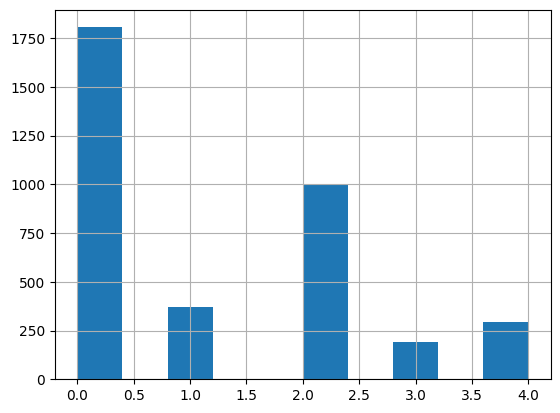

In [13]:
print(df['diagnosis'].hist())

In [14]:
print(df['diagnosis'].value_counts())

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [15]:
import os

files = os.listdir("/content/dataset/drd/train_images")


In [16]:
print(len(files))

3662


In [17]:
import cv2
path ="/content/dataset/drd/"
img_list=[]
for i in files[0:20]:
    image=cv2.imread(path + "train_images/"+i)
    image = cv2.resize(image,(400,400))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_list.append(image)





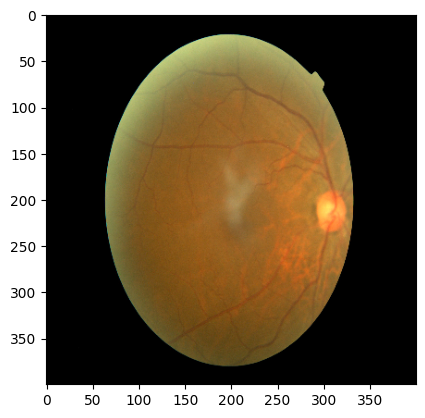

In [18]:
import matplotlib.pyplot as plt
plt.imshow(img_list[0])
plt.show()

In [19]:
copy = img_list[0].copy()

In [20]:
copy = cv2.cvtColor(copy, cv2.COLOR_RGB2GRAY)

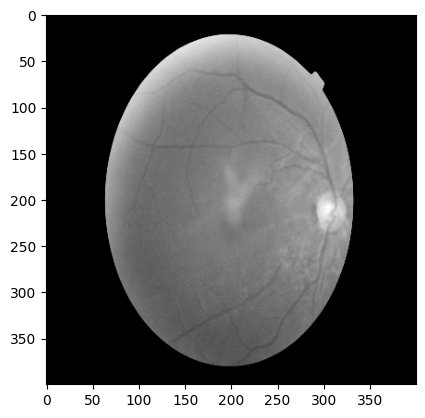

In [21]:
plt.imshow(copy, cmap="gray")
plt.show()

In [22]:
print(copy.shape)

(400, 400)


In [23]:
blur = cv2.GaussianBlur(copy,(5,5),0)

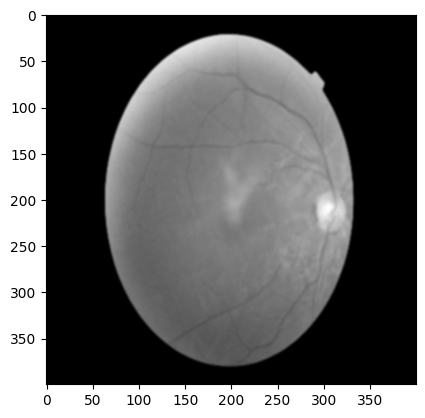

In [24]:
plt.imshow(blur, cmap="gray")
plt.show()

In [25]:
thresh= cv2.threshold(blur, 10, 255, cv2.THRESH_BINARY)[1]

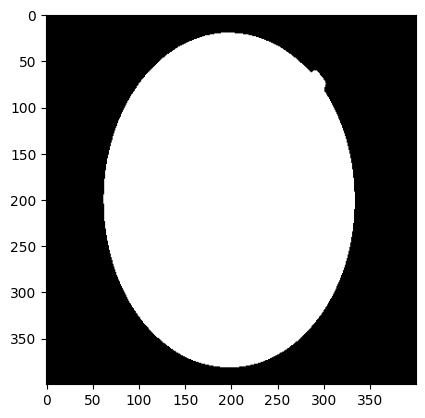

In [26]:
plt.imshow(thresh, cmap="gray")
plt.show()

In [27]:
contour = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [28]:
print(contour)

((array([[[189,  20]],

       [[188,  21]],

       [[182,  21]],

       [[181,  22]],

       [[177,  22]],

       [[176,  23]],

       [[172,  23]],

       [[171,  24]],

       [[169,  24]],

       [[168,  25]],

       [[166,  25]],

       [[165,  26]],

       [[163,  26]],

       [[162,  27]],

       [[160,  27]],

       [[159,  28]],

       [[158,  28]],

       [[157,  29]],

       [[155,  29]],

       [[154,  30]],

       [[153,  30]],

       [[152,  31]],

       [[151,  31]],

       [[150,  32]],

       [[149,  32]],

       [[148,  33]],

       [[147,  33]],

       [[146,  34]],

       [[145,  34]],

       [[144,  35]],

       [[143,  35]],

       [[141,  37]],

       [[140,  37]],

       [[138,  39]],

       [[137,  39]],

       [[135,  41]],

       [[134,  41]],

       [[132,  43]],

       [[131,  43]],

       [[127,  47]],

       [[126,  47]],

       [[107,  66]],

       [[107,  67]],

       [[103,  71]],

       [[103,  72]],

       [

In [29]:
print(contour[0][0])

[[[189  20]]

 [[188  21]]

 [[182  21]]

 [[181  22]]

 [[177  22]]

 [[176  23]]

 [[172  23]]

 [[171  24]]

 [[169  24]]

 [[168  25]]

 [[166  25]]

 [[165  26]]

 [[163  26]]

 [[162  27]]

 [[160  27]]

 [[159  28]]

 [[158  28]]

 [[157  29]]

 [[155  29]]

 [[154  30]]

 [[153  30]]

 [[152  31]]

 [[151  31]]

 [[150  32]]

 [[149  32]]

 [[148  33]]

 [[147  33]]

 [[146  34]]

 [[145  34]]

 [[144  35]]

 [[143  35]]

 [[141  37]]

 [[140  37]]

 [[138  39]]

 [[137  39]]

 [[135  41]]

 [[134  41]]

 [[132  43]]

 [[131  43]]

 [[127  47]]

 [[126  47]]

 [[107  66]]

 [[107  67]]

 [[103  71]]

 [[103  72]]

 [[100  75]]

 [[100  76]]

 [[ 98  78]]

 [[ 98  79]]

 [[ 96  81]]

 [[ 96  82]]

 [[ 94  84]]

 [[ 94  85]]

 [[ 92  87]]

 [[ 92  88]]

 [[ 91  89]]

 [[ 91  90]]

 [[ 90  91]]

 [[ 90  92]]

 [[ 88  94]]

 [[ 88  95]]

 [[ 87  96]]

 [[ 87  97]]

 [[ 86  98]]

 [[ 86  99]]

 [[ 85 100]]

 [[ 85 101]]

 [[ 84 102]]

 [[ 84 103]]

 [[ 83 104]]

 [[ 83 105]]

 [[ 82

In [30]:
contour = contour[0][0]

In [31]:
contour = contour[:,0,:]

In [32]:
left = tuple(contour[contour[:,0].argmin()])
right = tuple(contour[contour[:,0].argmax()])
top = tuple(contour[contour[:,1].argmin()])
bottom = tuple(contour[contour[:,1].argmax()])

In [33]:
print(left, right, top, bottom)

(np.int32(62), np.int32(195)) (np.int32(333), np.int32(210)) (np.int32(189), np.int32(20)) (np.int32(188), np.int32(381))


In [34]:
x1 = left[0]
y1 = top[1]
x2 = right[0]
y2 = bottom[1]

In [35]:
original = img_list[0].copy()

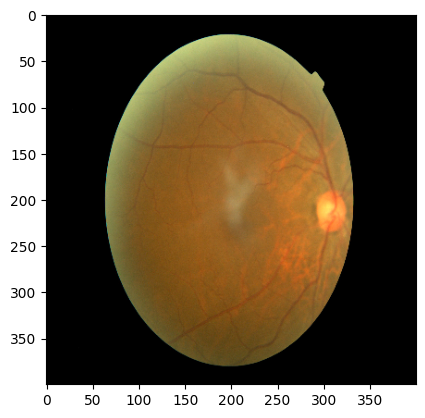

In [36]:
plt.imshow(original)
plt.show()

In [37]:
crop_first = original[y1:y2, x1:x2]

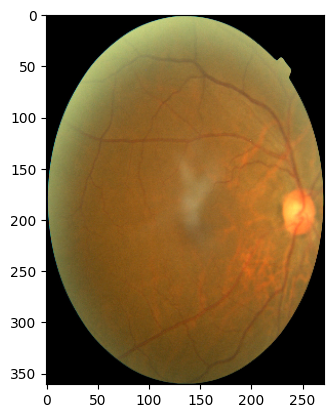

In [38]:
plt.imshow(crop_first)
plt.show()

In [39]:
crop_first = cv2.resize(crop_first,(400,400))

In [40]:
x= int((x2-x1)*4//100)
y= int((y2-y1)*5//100)

In [41]:
crop_first = original[y1+y:y2-y, x1+x:x2-x]

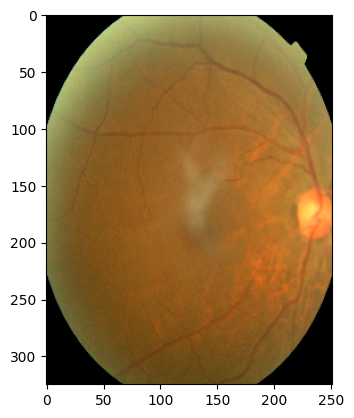

In [42]:
plt.imshow(crop_first)
plt.show()

In [43]:
crop_last = cv2.resize(crop_first,(400,400))

In [44]:
lab = cv2.cvtColor(crop_last, cv2.COLOR_RGB2LAB)

In [45]:
print(lab.shape)

(400, 400, 3)


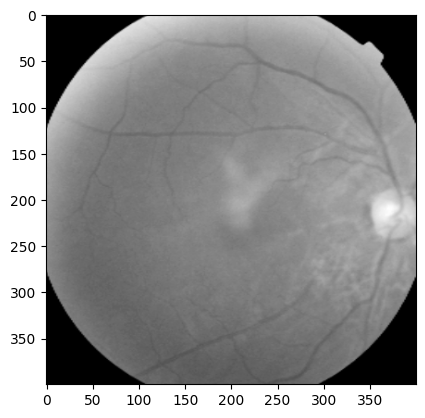

In [46]:
l,a,b= cv2.split(lab)
plt.imshow(l, cmap="gray")
plt.show()

In [47]:
flat = l.flatten()
print(flat.shape)

(160000,)


In [48]:
clahe= cv2.createCLAHE(clipLimit=7.0, tileGridSize=(8,8))
cl= clahe.apply(l)

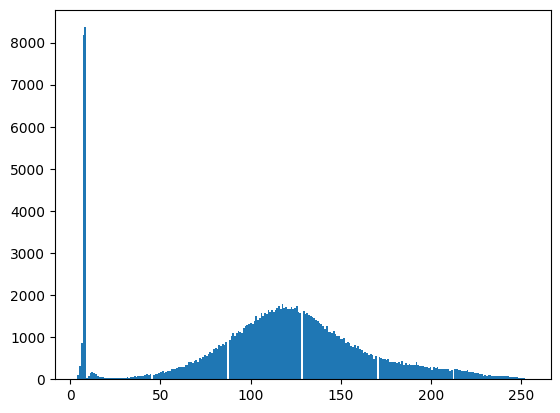

In [49]:
plt.hist(cl.flatten(),bins=256)
plt.show()

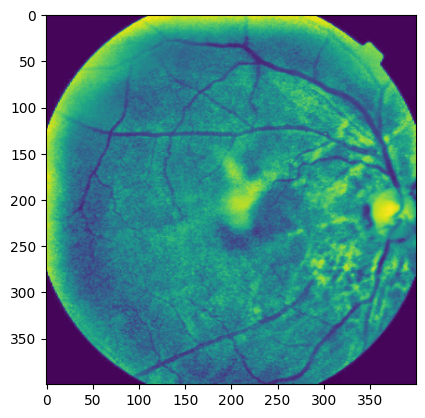

In [50]:
plt.imshow(cl)
plt.show()

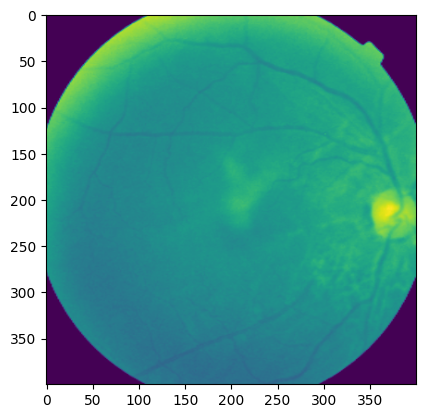

In [51]:
plt.imshow(l)
plt.show()

In [52]:
limg = cv2.merge((cl,a,b))

In [53]:
last = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

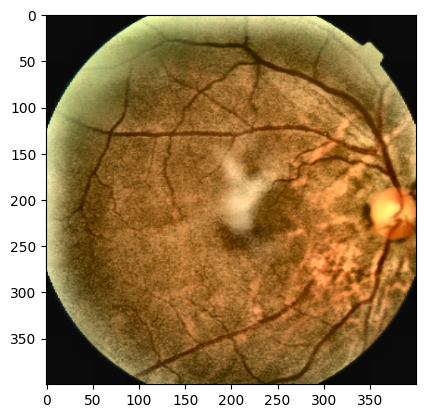

In [54]:
plt.imshow(last)
plt.show()

In [55]:
med_last = cv2.medianBlur(last,3)

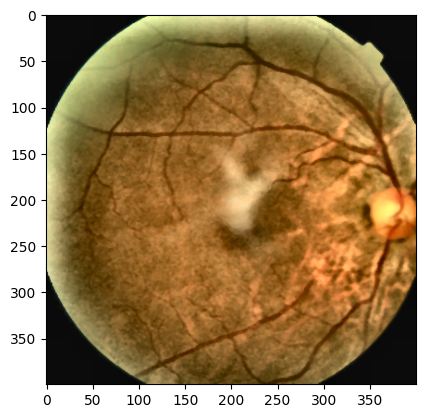

In [56]:
plt.imshow(med_last)
plt.show()

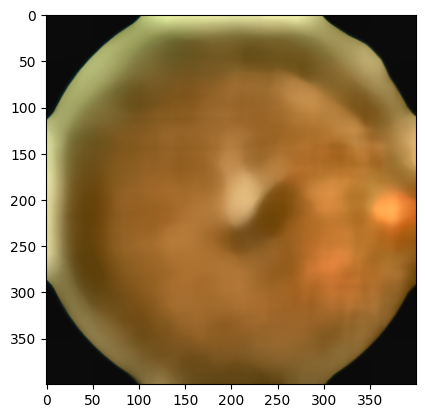

In [57]:
bg = cv2.medianBlur(last,37)
plt.imshow(bg)
plt.show()

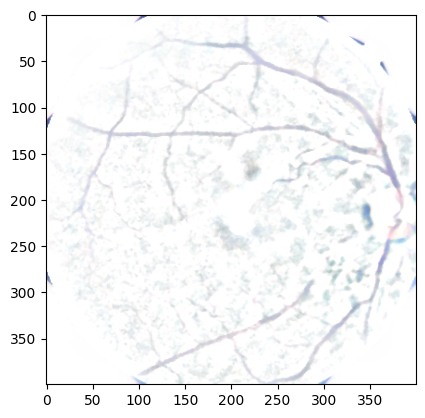

In [58]:
mask = cv2.addWeighted(med_last,1,bg,-1,255)
plt.imshow(mask)
plt.show()

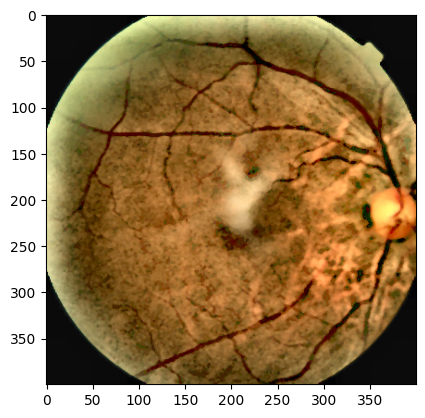

In [59]:
last_img = cv2.bitwise_and(mask,med_last)
plt.imshow(last_img)
plt.show()

In [60]:
df['filename'] = df['id_code'] + ".png"

In [61]:
img_list = []
y_labels = []
from tqdm.notebook import tqdm as tq
image_dir = "/content/dataset/drd/train_images"


for fname, label in tq(zip(df['filename'], df['diagnosis']), total=len(df)):
    img_path = os.path.join(image_dir, fname)

    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: {fname} could not be read.")
        continue

    try:
        image = cv2.resize(image, (400, 400))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        copy = image.copy()
        copy = cv2.cvtColor(copy, cv2.COLOR_RGB2GRAY)
        blur = cv2.GaussianBlur(copy,(5,5),0)
        thresh = cv2.threshold(blur, 10, 255, cv2.THRESH_BINARY)[1]
        contour = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour = contour[0][0]
        contour = contour[:,0,:]
        left = tuple(contour[contour[:,0].argmin()])
        right = tuple(contour[contour[:,0].argmax()])
        top = tuple(contour[contour[:,1].argmin()])
        bottom = tuple(contour[contour[:,1].argmax()])
        x= int((right[0]-left[0])*4//100)
        y= int((bottom[1]-top[1])*5//100)
        x1 = left[0] + x
        x2 = right[0] - x
        y1 = top[1] + y
        y2 = bottom[1] - y

        if x2 - x1 > 100 and y2 - y1 > 100:
            copy2 = image[top[1]+y:bottom[1]-y, left[0]+x:right[0]-x]
            copy2 = cv2.resize(copy2,(400,400))
        else:
            continue

        lab = cv2.cvtColor(copy2, cv2.COLOR_RGB2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=7.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl,a,b))
        last = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        med_last = cv2.medianBlur(last, 3)
        bg = cv2.medianBlur(last, 37)
        mask = cv2.addWeighted(med_last, 1, bg, -1, 255)
        last_img = cv2.bitwise_and(mask, med_last)


        img_list.append(last_img)
        y_labels.append(label)

    except Exception as e:
        print(f"Skipped {fname} due to error: {e}")
        continue


  0%|          | 0/3662 [00:00<?, ?it/s]

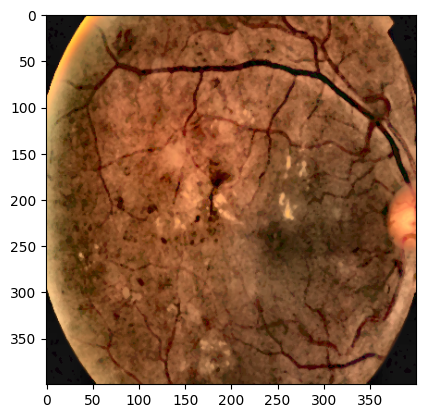

In [63]:
import matplotlib.pyplot as plt
plt.imshow(img_list[0])
plt.show()

In [64]:
fig = plt.figure(figsize=(20,12))

for i in range(12):
    img = img_list[i]
    fig.add_subplot(3,4,i+1)
    plt.imshow(img)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [65]:
print(y_labels)

[2, 4, 1, 0, 0, 4, 2, 2, 1, 0, 2, 0, 3, 1, 0, 2, 0, 0, 2, 2, 0, 1, 2, 0, 2, 0, 0, 0, 0, 0, 4, 2, 4, 2, 0, 0, 4, 0, 4, 2, 2, 4, 2, 1, 2, 4, 0, 3, 2, 2, 2, 2, 0, 3, 0, 2, 1, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 3, 0, 2, 0, 2, 0, 1, 3, 1, 0, 2, 0, 0, 3, 4, 2, 2, 0, 0, 0, 0, 0, 3, 1, 0, 2, 2, 0, 0, 4, 4, 0, 0, 1, 2, 4, 0, 0, 0, 0, 0, 0, 3, 0, 2, 2, 0, 4, 0, 0, 1, 0, 2, 0, 2, 2, 2, 1, 0, 0, 1, 0, 0, 2, 0, 2, 1, 4, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 3, 2, 0, 3, 0, 0, 0, 0, 4, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 1, 3, 1, 0, 4, 0, 0, 2, 4, 0, 1, 0, 3, 0, 2, 2, 0, 1, 0, 3, 1, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0, 4, 1, 1, 2, 4, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 3, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 3, 0, 1, 2, 0, 3, 0, 0, 0, 3, 2, 0, 4, 0, 0, 4, 3, 4, 2, 1, 0, 2, 0, 0, 0, 0, 0, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 4, 0, 2, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 2, 2, 3, 0, 3, 2, 1, 0, 2, 2, 1, 0, 1, 

In [66]:
y_train = pd.get_dummies(y_labels).astype(int).values


In [67]:
print(y_train)

[[0 0 1 0 0]
 [0 0 0 0 1]
 [0 1 0 0 0]
 ...
 [0 0 1 0 0]
 [1 0 0 0 0]
 [0 0 1 0 0]]


In [68]:
import numpy as np
y_train_last = np.ones_like(y_train, dtype='uint8')

In [69]:
y_train_last[:,4] = y_train[:,4]

In [70]:
for i in range(3, -1, -1):
    y_train_last[:,i] = np.logical_or(y_train[:,i], y_train_last[:,i+1])


In [71]:
print(y_train_last)

[[1 1 1 0 0]
 [1 1 1 1 1]
 [1 1 0 0 0]
 ...
 [1 1 1 0 0]
 [1 0 0 0 0]
 [1 1 1 0 0]]


In [72]:
import numpy as np
X_train = np.array(img_list)

In [73]:
print(X_train.shape)

(3485, 400, 400, 3)


In [74]:
print(y_train_last.shape)


(3485, 5)


In [75]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)


In [76]:
from collections import Counter
import numpy as np

y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)

print("Train class distribution:", dict(Counter(y_train_labels)))
print("Validation class distribution:", dict(Counter(y_val_labels)))


Train sınıf dağılımı: {np.int64(2): 980, np.int64(4): 290, np.int64(1): 354, np.int64(0): 1675, np.int64(3): 186}
Validation sınıf dağılımı: {np.int64(0): 251, np.int64(1): 53, np.int64(2): 147, np.int64(4): 44, np.int64(3): 28}


In [77]:
import cv2
import numpy as np

def resize_images(images, target_size=(456, 456)):
    resized_images = []
    for img in images:
        resized = cv2.resize(img, target_size)
        resized_images.append(resized)
    return np.array(resized_images)

X_train_resized = resize_images(X_train)
X_val_resized = resize_images(X_val)


In [80]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 8

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

data_generator = train_datagen.flow(
    X_train_resized,
    y_train,
    batch_size=batch_size,
    shuffle=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow(
    X_val_resized,
    y_val,
    batch_size=batch_size,
    shuffle=False
)





In [81]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers, layers

model = Sequential()
model.add(EfficientNetB5(include_top=False, weights='imagenet', input_shape=(456, 456, 3)))
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(5, activation="sigmoid"))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

lr=ReduceLROnPlateau(monitor="val_loss",
                     mode="auto",
                     factor=0.25,
                     min_lr=0.000001,
                     )

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(data_generator,
                             steps_per_epoch=len(X_train_resized) // batch_size,
                             epochs=50,
                             validation_data=(X_val_resized, y_val),
                             callbacks=[lr, early_stop])

Epoch 1/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 503s 757ms/step - accuracy: 0.6332 - loss: 0.3716 - val_accuracy: 0.8069 - val_loss: 0.1751 - learning_rate: 1.0000e-04
Epoch 2/50
  1/435 ━━━━━━━━━━━━━━━━━━━━ 3:35 496ms/step - accuracy: 0.7500 - loss: 0.1813

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


435/435 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7500 - loss: 0.1813 - val_accuracy: 0.8031 - val_loss: 0.1747 - learning_rate: 1.0000e-04
Epoch 3/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 224s 514ms/step - accuracy: 0.7886 - loss: 0.2022 - val_accuracy: 0.8509 - val_loss: 0.1415 - learning_rate: 1.0000e-04
Epoch 4/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8750 - loss: 0.2562 - val_accuracy: 0.8451 - val_loss: 0.1423 - learning_rate: 1.0000e-04
Epoch 5/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 224s 514ms/step - accuracy: 0.8329 - loss: 0.1682 - val_accuracy: 0.8795 - val_loss: 0.1111 - learning_rate: 1.0000e-04
Epoch 6/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 1.0000 - loss: 0.0529 - val_accuracy: 0.8776 - val_loss: 0.1111 - learning_rate: 1.0000e-04
Epoch 7/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 223s 513ms/step - accuracy: 0.8496 - loss: 0.1531 - val_accuracy: 0.9044 - val_loss: 0.0966 - learning_rate: 1.0000e-04
Epoch 8/50
435/435 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accur

17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step
Classification Report (Validation Set):
                  precision    recall  f1-score   support

           No DR     1.0000    1.0000    1.0000       251
            Mild     0.9455    0.9811    0.9630        53
        Moderate     0.9863    0.9796    0.9829       147
          Severe     0.9032    1.0000    0.9492        28
Proliferative DR     1.0000    0.9091    0.9524        44

        accuracy                         0.9847       523
       macro avg     0.9670    0.9740    0.9695       523
    weighted avg     0.9854    0.9847    0.9847       523



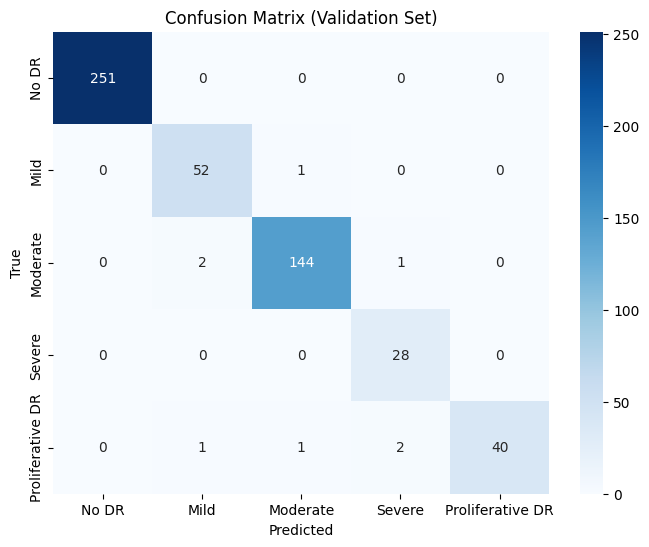

In [84]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_val_pred_probs = model.predict(X_val_resized)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

if y_val.shape[1] > 1:
    y_val_true = np.argmax(y_val, axis=1)
else:
    y_val_true = y_val

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']  # kendine göre düzenle

print("Classification Report (Validation Set):")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Set)")
plt.show()


In [141]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.uint8(0): np.int64(8940), np.uint8(1): np.int64(6620)}
